In [1]:
import pandas as pd
from neuralprophet import NeuralProphet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# PyTorch 2.6+ / Lightning LR-finder checkpoints pickle NeuralProphet config objects.
import torch
if not hasattr(torch, "_torch_load_orig"):
    torch._torch_load_orig = torch.load
if getattr(torch.load, "_np_patched", False) is False:
    def _torch_load_np(*args, **kwargs):
        kwargs["weights_only"] = False
        return torch._torch_load_orig(*args, **kwargs)
    _torch_load_np._np_patched = True
    torch.load = _torch_load_np

/Users/zhangyue/Workspace/github/learning-toy-examples/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_pedestrians_covid.csv')
df['ds'] = pd.to_datetime(df['ds'])
print(df.shape)
df.head()

(1490, 2)


,ds,y
0,2017-06-02,39230
1,2017-06-03,35290
2,2017-06-04,27083
3,2017-06-05,28727
4,2017-06-06,30315


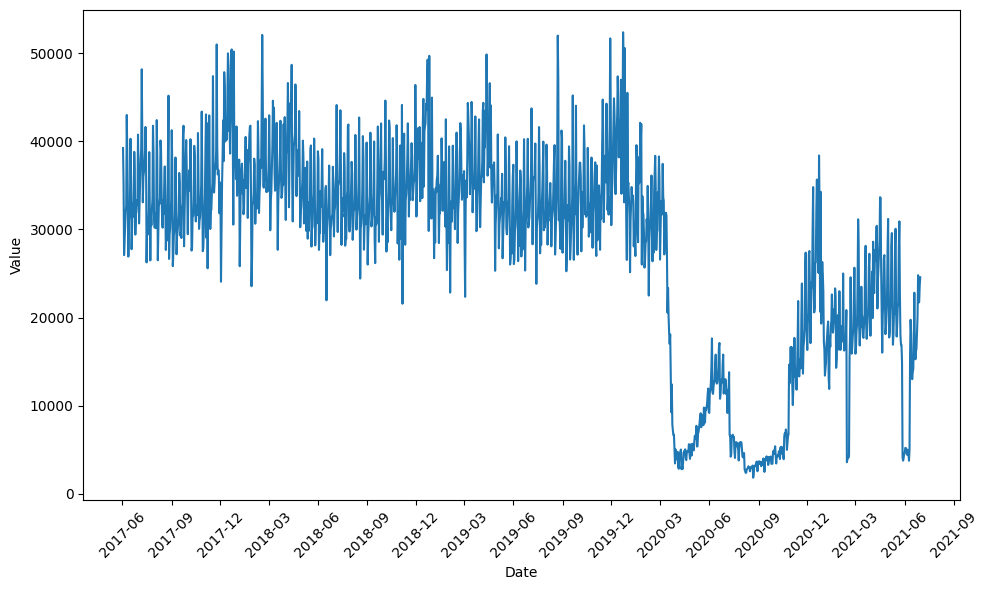

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'])

plt.xlabel('Date')
plt.ylabel('Value')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pre-Covid

(944, 2)


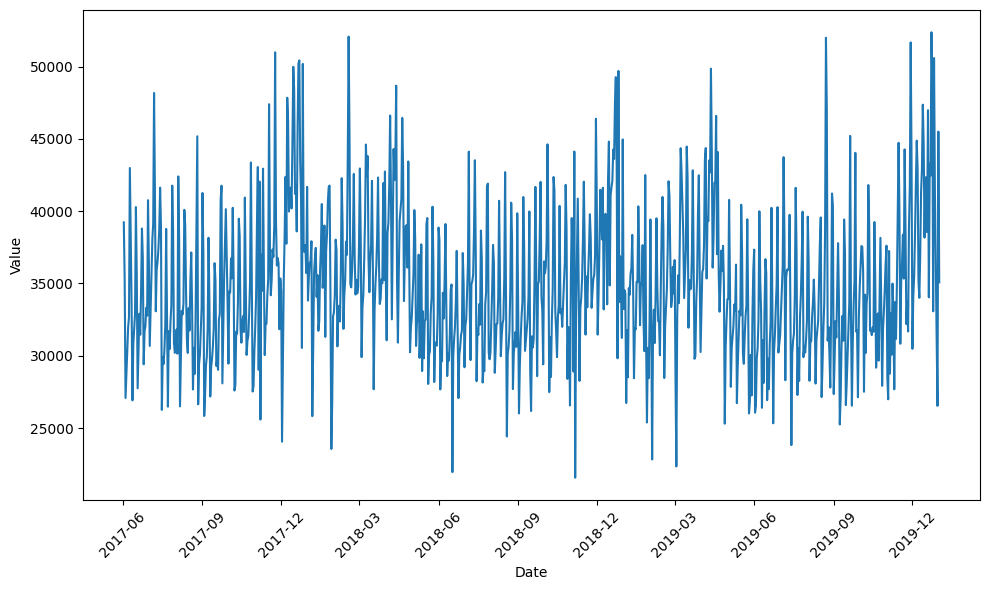

In [4]:
df_pre = df[df['ds'] <= "2020-01-01"]
print(df_pre.shape)

plt.figure(figsize=(10, 6))
plt.plot(df_pre['ds'], df_pre['y'])

plt.xlabel('Date')
plt.ylabel('Value')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# no trend
m = NeuralProphet(growth="off", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m.set_plotting_backend("matplotlib")
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
X = df_pre[df_pre['ds'] <= "2019-01-01"]
test = df_pre[df_pre['ds'] > "2019-01-01"]
m.fit(X)

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.827% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 130


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (19) is too small than the required number                     for the learning rate finder (220). The results might not be optimal.
Finding best initial lr: 100%|██████████| 220/220 [00:01<00:00, 150.12it/s]


Training: |          | 0/? [00:12<?, ?it/s, v_num=3, train_loss=0.0238, reg_loss=0.000, MAE=2.38e+3, RMSE=3.33e+3, Loss=0.0267, RegLoss=0.000]


,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,1.109657,0.0,36497.406250,41801.761719,1.093158,0.0,0
1,0.949586,0.0,32086.816406,37157.507812,0.961499,0.0,1
2,0.804857,0.0,27288.875000,32241.746094,0.800148,0.0,2
3,0.661025,0.0,23005.140625,27344.425781,0.661156,0.0,3
4,0.510501,0.0,18607.876953,22877.421875,0.508866,0.0,4
...,...,...,...,...,...,...,...
125,0.023752,0.0,2377.549561,3338.768066,0.026700,0.0,125
126,0.023732,0.0,2243.302734,3129.491455,0.023177,0.0,126
127,0.023797,0.0,2397.643311,3303.674561,0.026278,0.0,127
128,0.023732,0.0,2241.624268,3104.181396,0.023149,0.0,128


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 168.44it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.



fit MAE is: 2779.72
fit MAPE is: 0.08


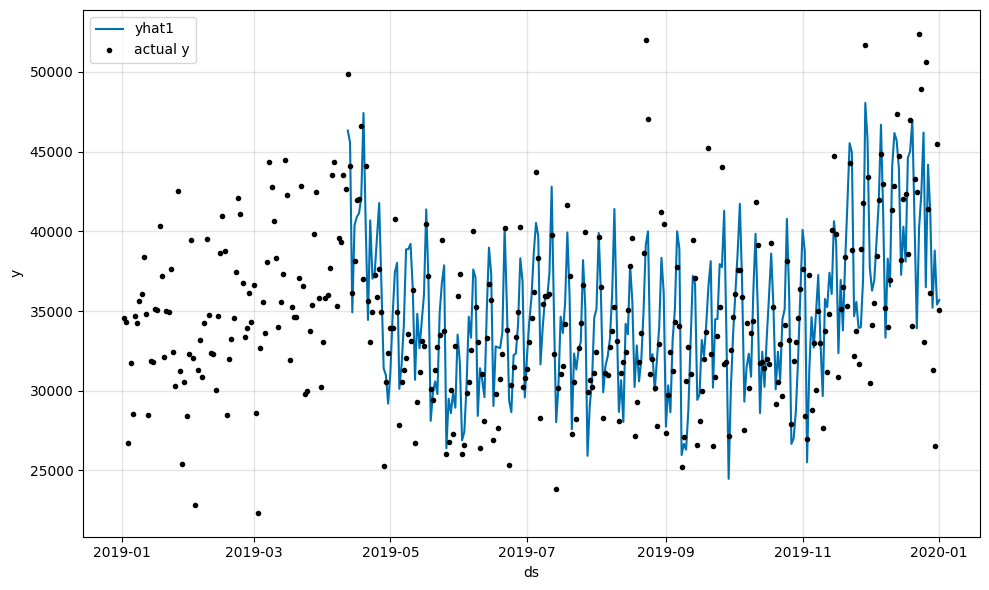

In [23]:
# prophet MAE is 2468
y_hat = m.predict(test)
# get mae and mape
mae = np.nanmean(np.abs(y_hat['yhat1'].values - y_hat['y'].values))
mape = np.nanmean(np.abs(y_hat['yhat1'].values - y_hat['y'].values) / y_hat['y'].values)
print(f"fit MAE is: {mae:.2f}")
print(f"fit MAPE is: {mape:.2f}")
m.plot(y_hat)

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


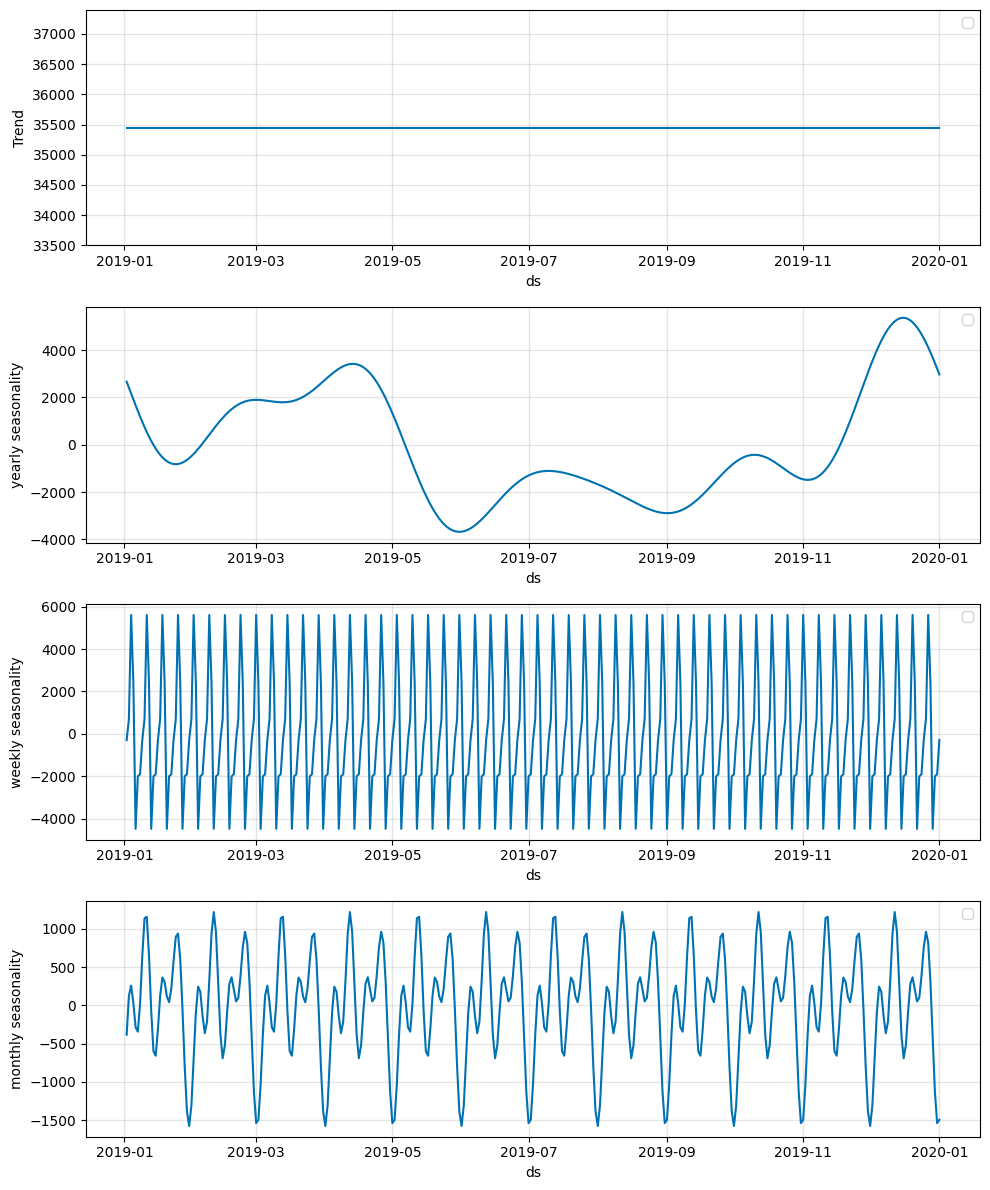

In [13]:
m.plot_components(y_hat)

In [15]:
fact = pd.DataFrame({"pred": pred.values, "actual": actual.values})
fact.head()

,pred,actual
0,36667.183594,34536
1,37723.183594,34299
2,42361.089844,26737
3,38676.382812,31750
4,31179.458984,28513


# Add auto-regression Lags

In [24]:
m = NeuralProphet(growth="off", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, n_lags=10)
m.set_plotting_backend("matplotlib")
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
X = df_pre[df_pre['ds'] <= "2019-01-01"]
test = df_pre[df_pre['ds'] > "2019-01-01"]
m.fit(X)

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.827% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 140


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (18) is too small than the required number                     for the learning rate finder (220). The results might not be optimal.
Finding best initial lr: 100%|██████████| 220/220 [00:01<00:00, 133.47it/s]


Training: |          | 0/? [00:14<?, ?it/s, v_num=6, train_loss=0.0225, reg_loss=0.000, MAE=2.12e+3, RMSE=3.01e+3, Loss=0.0224, RegLoss=0.000]


,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,0.643445,0.0,22568.339844,28182.019531,0.642514,0.0,0
1,0.498911,0.0,18119.574219,22976.621094,0.498751,0.0,1
2,0.391649,0.0,14885.640625,19140.433594,0.392563,0.0,2
3,0.300008,0.0,12021.495117,15631.973633,0.300156,0.0,3
4,0.225474,0.0,9589.237305,12660.488281,0.225334,0.0,4
...,...,...,...,...,...,...,...
135,0.022487,0.0,2125.687988,3070.895508,0.022486,0.0,135
136,0.022484,0.0,2124.653320,3067.311523,0.022501,0.0,136
137,0.022482,0.0,2132.161621,3089.711914,0.022681,0.0,137
138,0.022484,0.0,2118.352539,3032.436523,0.022341,0.0,138


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 44.38it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.



fit MAE is: 2355.29
fit MAPE is: 0.07


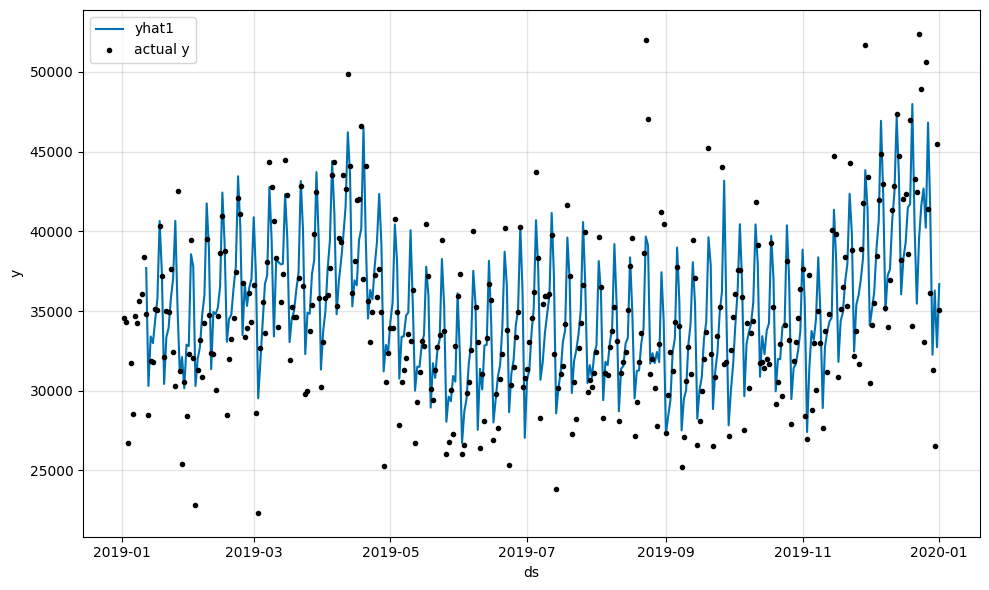

In [25]:
# prophet MAE is 2468
y_hat = m.predict(test)
mae = np.nanmean(np.abs(y_hat['yhat1'].values - y_hat['y'].values))
mape = np.nanmean(np.abs(y_hat['yhat1'].values - y_hat['y'].values) / y_hat['y'].values)
print(f"fit MAE is: {mae:.2f}")
print(f"fit MAPE is: {mape:.2f}")
m.plot(y_hat)

# Add Holidays

In [26]:
import holidays

years = [2017, 2018, 2019, 2020]
vic_holidays = holidays.Australia(years=years, subdiv='VIC')
holiday_list = []
for date, name in sorted(vic_holidays.items()):
    holiday_list.append({
        'ds': date,
        'holiday': name,
        'lower_window': 0,
        'upper_window': 0
    })

holidays_df = pd.DataFrame(holiday_list)
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

# Impact starts 1 day before for Melbourne Cup (Monday)
holidays_df.loc[holidays_df['holiday'] == 'Melbourne Cup', 'lower_window'] = -1

# Easter Friday impact extends through the weekend
holidays_df.loc[holidays_df['holiday'] == 'Good Friday', 'upper_window'] = 3
holidays_df.head()

,ds,holiday,lower_window,upper_window
0,2017-01-01,New Year's Day,0,0
1,2017-01-02,New Year's Day (observed),0,0
2,2017-01-26,Australia Day,0,0
3,2017-03-13,Labour Day,0,0
4,2017-04-14,Good Friday,0,3


In [28]:
m = NeuralProphet(growth="off", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, n_lags=10)
m.add_country_holidays(country_name='Australia')
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
X = df_pre[df_pre['ds'] <= "2019-01-01"]
test = df_pre[df_pre['ds'] > "2019-01-01"]
m.fit(X)

y_hat = m.predict(test)
_ = m.plot(y_hat)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.827% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 140


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (18) is too small than the required number                     for the learning rate finder (220). The results might not be optimal.
Finding best initial lr: 100%|██████████| 220/220 [00:01<00:00, 134.92it/s]


Training: |          | 0/? [00:16<?, ?it/s, v_num=7, train_loss=0.0194, reg_loss=0.000, MAE=1.97e+3, RMSE=2.82e+3, Loss=0.0193, RegLoss=0.000]

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  9.76it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.


In [29]:
y_hat = m.predict(test)
mae = np.nanmean(np.abs(y_hat['yhat1'].values - y_hat['y'].values))
mape = np.nanmean(np.abs(y_hat['yhat1'].values - y_hat['y'].values) / y_hat['y'].values)
print(f"fit MAE is: {mae:.2f}")
print(f"fit MAPE is: {mape:.2f}")
m.plot(y_hat)

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.726% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 48.52it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.



fit MAE is: 2189.71
fit MAPE is: 0.06


# Full Dataset

## Add Covid as Holidays

In [59]:
m = NeuralProphet(growth="off", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, n_lags=10, n_forecasts=366)
m.set_plotting_backend("matplotlib")
m.add_country_holidays(country_name='Australia')
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.add_events(events="lockdown_1", lower_window=0, upper_window=77)
m.add_events(events="lockdown_2", lower_window=0, upper_window=110)
m.add_events(events="lockdown_3", lower_window=0, upper_window=4)
m.add_events(events="lockdown_4", lower_window=0, upper_window=13)
events_df = pd.DataFrame(
    {
        "event": ["lockdown_1", "lockdown_2", "lockdown_3", "lockdown_4"],
        "ds": pd.to_datetime(
            [
                "2020-03-21",
                "2020-07-09",
                "2021-02-13",
                "2021-05-28",
            ]
        ),
    }
)

df_all = m.create_df_with_events(df, events_df)

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.933% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 110


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (35) is too small than the required number                     for the learning rate finder (230). The results might not be optimal.
Finding best initial lr: 100%|██████████| 230/230 [00:03<00:00, 65.84it/s]


Training: |          | 0/? [00:37<?, ?it/s, v_num=12, train_loss=0.0221, reg_loss=0.000, MAE=4.01e+3, RMSE=5.3e+3, Loss=0.0221, RegLoss=0.000] 

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.933% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
WARNING - (NP.data.splitting._make_future_dataframe) - Future values not supplied for user specified events. All events being treated as not occurring in future
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 366.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.946% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.946% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Dropped 366 rows at the end w


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  3.23it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


WARNING - (NP.plotting.plot) - Legend is available only for the ten first handles


Text(0.5, 1.0, 'Prophet with COVID')

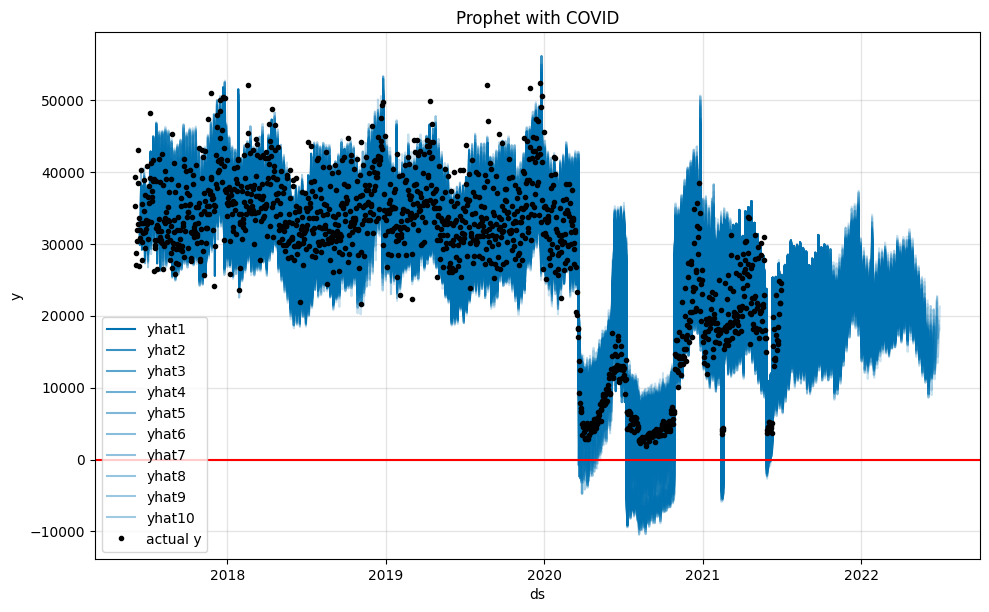

In [ ]:
m.fit(df_all)
# the periods to predict must equal to n_forecasts during model creation
future = m.make_future_dataframe(df_all, n_historic_predictions=True, periods=365)
forecast = m.predict(future)

m.plot(forecast)
plt.axhline(y=0, color='red')
plt.title('Prophet with COVID')


# Conditional Seasonality

The weekly pedetrian behaviour could change before and after COVID.

__NOTE: CONDITION MUST BE BOOLEAN.__

In [63]:
df2 = df_all.copy()

df2['pre_covid'] = pd.to_datetime(df2['ds']) < pd.to_datetime('2020-03-21')
df2['post_covid'] = ~df2['pre_covid']

In [66]:
m2 = NeuralProphet(growth="off", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, n_lags=10, n_forecasts=366)
m2.set_plotting_backend("matplotlib")
m2.add_country_holidays(country_name='Australia')
m2.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m2.add_events(events="lockdown_1", lower_window=0, upper_window=77)
m2.add_events(events="lockdown_2", lower_window=0, upper_window=110)
m2.add_events(events="lockdown_3", lower_window=0, upper_window=4)
m2.add_events(events="lockdown_4", lower_window=0, upper_window=13)

m2.add_seasonality(name="prexcovid", period=7, fourier_order=3, condition_name='pre_covid')  # indicator + fourier formulation
m2.add_seasonality(name="postxcovid", period=7, fourier_order=3, condition_name='post_covid')

m2.fit(df2)

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.933% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 110


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (35) is too small than the required number                     for the learning rate finder (230). The results might not be optimal.
Finding best initial lr: 100%|██████████| 230/230 [00:03<00:00, 67.29it/s]


Training: |          | 0/? [00:44<?, ?it/s, v_num=14, train_loss=0.022, reg_loss=0.000, MAE=3.95e+3, RMSE=5.27e+3, Loss=0.022, RegLoss=0.000]  


,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,1.405656,0.0,81623.156250,103574.515625,1.404857,0.0,0
1,0.941181,0.0,56343.667969,72238.898438,0.940423,0.0,1
2,0.591969,0.0,37260.945312,48141.222656,0.591283,0.0,2
3,0.325347,0.0,22589.160156,29489.269531,0.324885,0.0,3
4,0.143615,0.0,12233.968750,15950.985352,0.143425,0.0,4
...,...,...,...,...,...,...,...
105,0.021994,0.0,3963.250488,5274.833008,0.021987,0.0,105
106,0.021978,0.0,3955.860352,5270.936035,0.022001,0.0,106
107,0.021989,0.0,3961.882080,5275.223145,0.021983,0.0,107
108,0.021975,0.0,3958.970459,5271.911621,0.021996,0.0,108


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.933% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
WARNING - (NP.data.splitting._make_future_dataframe) - Future values not supplied for user specified events. All events being treated as not occurring in future
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.946% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.946% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Dropped 366 rows at the end with NaNs in 'y' column.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  3.90it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


WARNING - (NP.plotting.plot) - Legend is available only for the ten first handles


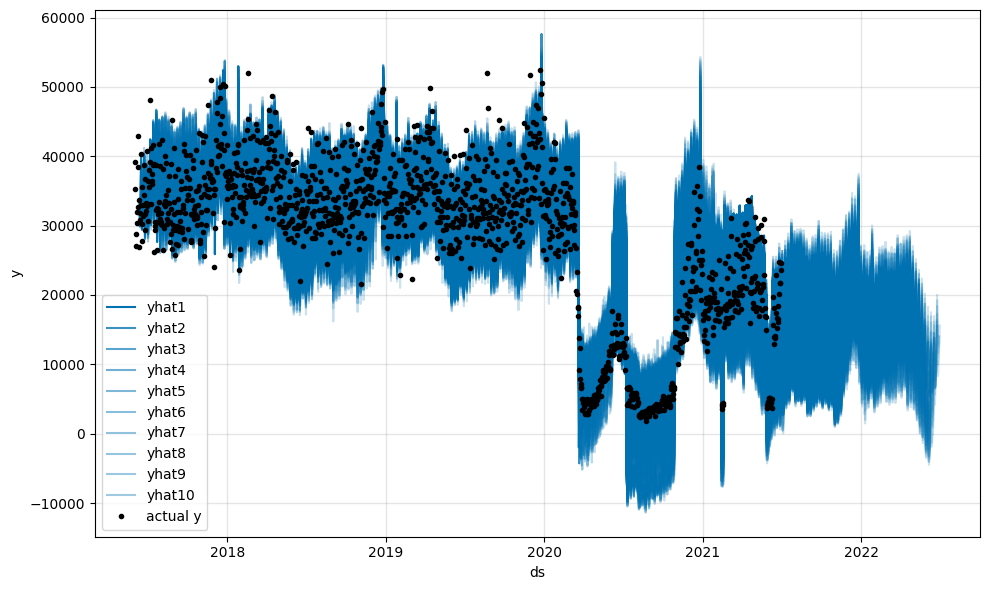

In [68]:
future2 = m2.make_future_dataframe(df2, periods=366, n_historic_predictions=True)
future2['pre_covid'] = pd.to_datetime(future2['ds']) < pd.to_datetime('2020-03-21')
future2['post_covid'] = ~future2['pre_covid']

forecast2 = m2.predict(future2)
_ = m2.plot(forecast2)

# Evaluation

In [70]:
m = NeuralProphet(growth="off", weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m.set_plotting_backend("matplotlib")
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)

df_train, df_test = m.split_df(df_pre, valid_p=0.2)
print(df_train.shape, df_test.shape)
metrics = m.fit(df_train, validation_df=df_test)
metrics

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.894% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.868% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


(756, 2) (188, 2)
Epoch 130: 100%|██████████| 130/130 [03:17<00:00,  0.66it/s]    

INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 120



Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (24) is too small than the required number                     for the learning rate finder (223). The results might not be optimal.
Finding best initial lr: 100%|██████████| 223/223 [00:01<00:00, 146.00it/s]


Training: |          | 0/? [00:16<?, ?it/s, v_num=16, MAE_val=2.64e+3, RMSE_val=3.7e+3, Loss_val=0.0422, RegLoss_val=0.000, train_loss=0.0247, reg_loss=0.000, MAE=2.29e+3, RMSE=3.2e+3, Loss=0.0248, RegLoss=0.000]  


,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,18196.343750,22738.361328,0.681495,0.0,0,0.682292,0.0,23013.013672,28295.843750,0.681933,0.0
1,14748.415039,18612.214844,0.531106,0.0,1,0.539404,0.0,18758.208984,23240.833984,0.537859,0.0
2,11709.614258,14750.657227,0.396899,0.0,2,0.402342,0.0,14731.175781,18458.902344,0.400930,0.0
3,8753.186523,11055.519531,0.269857,0.0,3,0.272838,0.0,10853.682617,13719.051758,0.271954,0.0
4,5683.579590,7221.750488,0.142406,0.0,4,0.152518,0.0,7179.433105,9056.350586,0.151236,0.0
...,...,...,...,...,...,...,...,...,...,...,...
115,2643.026855,3704.140869,0.042311,0.0,115,0.024748,0.0,2300.031006,3202.388428,0.024868,0.0
116,2645.221680,3704.913330,0.042341,0.0,116,0.024754,0.0,2290.935791,3184.720459,0.024612,0.0
117,2646.140869,3707.503418,0.042382,0.0,117,0.024773,0.0,2293.336670,3196.904297,0.024649,0.0
118,2642.756104,3700.463379,0.042251,0.0,118,0.024744,0.0,2311.234131,3198.647461,0.025302,0.0


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.894% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.894% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 71.28it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


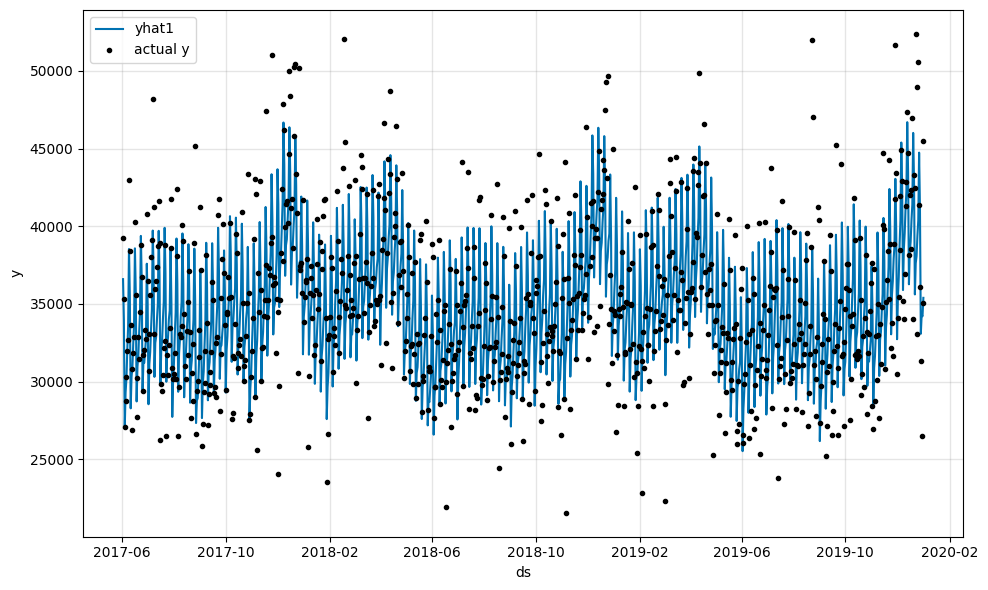

In [71]:
forecast = m.predict(df_pre)
m.plot(forecast)

In [4]:
import pandas as pd
from neuralprophet import NeuralProphet
import warnings
warnings.filterwarnings('ignore')

# PyTorch 2.6+ / Lightning LR-finder checkpoints pickle NeuralProphet config objects.
import torch
if not hasattr(torch, "_torch_load_orig"):
    torch._torch_load_orig = torch.load
if getattr(torch.load, "_np_patched", False) is False:
    def _torch_load_np(*args, **kwargs):
        kwargs["weights_only"] = False
        return torch._torch_load_orig(*args, **kwargs)
    _torch_load_np._np_patched = True
    torch.load = _torch_load_np


df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_pedestrians_covid.csv')
df['ds'] = pd.to_datetime(df['ds'])
print(df.shape)
df_pre = df[df['ds'] <= "2020-01-01"]

CV_CONFIG = {
    "k": 3,
    "fold_pct": 0.2,
    "fold_overlap_pct": 0.5,
    "global_model_cv_type": "global-time",  # "global-time" | "local" | "intersect"
    "freq": "auto",
}
FIT_CONFIG = {
    "learning_rate": None,  # None = LR finder; set e.g. 1.0 to skip
    "epochs": None,         # None = model default
}
VAL_METRIC_COLS = ["MAE_val", "RMSE_val", "Loss_val", "RegLoss_val"]
USE_BEST_EPOCH = False  # True: pick epoch with lowest Loss_val per fold


def make_model():
    m = NeuralProphet(
        growth="off",
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
    )
    m.set_plotting_backend("matplotlib")
    m.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    return m


def _fit_kwargs():
    kwargs = {}
    if FIT_CONFIG["learning_rate"] is not None:
        kwargs["learning_rate"] = FIT_CONFIG["learning_rate"]
    if FIT_CONFIG["epochs"] is not None:
        kwargs["epochs"] = FIT_CONFIG["epochs"]
    return kwargs


# 1) Build folds (only needs model config, not a prior fit)
m = make_model()
folds = m.crossvalidation_split_df(df_pre, **CV_CONFIG)
print(
    f"{len(folds)} folds (k={CV_CONFIG['k']}, fold_pct={CV_CONFIG['fold_pct']}):",
    [(tr.shape, va.shape) for tr, va in folds],
)

# 2) Train one fresh model per fold; collect validation metrics
fold_results = []

for i, (df_train, df_val) in enumerate(folds):
    train_cutoff = pd.to_datetime(df_train["ds"]).max()
    val_start = pd.to_datetime(df_val["ds"]).min()
    val_end = pd.to_datetime(df_val["ds"]).max()

    m_fold = make_model()
    metrics = m_fold.fit(df_train, validation_df=df_val, **_fit_kwargs())
    row = metrics.iloc[metrics["Loss_val"].idxmin()] if USE_BEST_EPOCH else metrics.iloc[-1]
    fold_results.append({
        "fold": i,
        "train_cutoff": train_cutoff,
        "val_start": val_start,
        "val_end": val_end,
        **{c: row[c] for c in VAL_METRIC_COLS if c in row},
    })
    print(
        f"fold {i} (train through {train_cutoff.date()}, val {val_start.date()}–{val_end.date()}):",
        {c: round(row[c], 4) for c in VAL_METRIC_COLS if c in row},
    )

cv_metrics = pd.DataFrame(fold_results)
cv_avg = cv_metrics[VAL_METRIC_COLS].mean()
cv_std = cv_metrics[VAL_METRIC_COLS].std()

print("\nPer-fold validation metrics:")
display(cv_metrics)

print(f"\nMean ± std across {CV_CONFIG['k']} folds:")
for col in VAL_METRIC_COLS:
    print(f"  {col}: {cv_avg[col]:.4f} ± {cv_std[col]:.4f}")

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.894% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.824% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided

(1490, 2)
3 folds (k=3, fold_pct=0.2): [((568, 2), (188, 2)), ((662, 2), (188, 2)), ((756, 2), (188, 2))]
Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (18) is too small than the required number                     for the learning rate finder (220). The results might not be optimal.
Finding best initial lr: 100%|██████████| 220/220 [00:01<00:00, 163.92it/s]


Training: |          | 0/? [00:15<?, ?it/s, v_num=23, MAE_val=2.89e+3, RMSE_val=3.92e+3, Loss_val=0.0485, RegLoss_val=0.000, train_loss=0.0218, reg_loss=0.000, MAE=2.16e+3, RMSE=3.02e+3, Loss=0.022, RegLoss=0.000] 

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.849% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 130


...


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (24) is too small than the required number                     for the learning rate finder (223). The results might not be optimal.
Finding best initial lr: 100%|██████████| 223/223 [00:01<00:00, 200.48it/s]


Training: |          | 0/? [00:14<?, ?it/s, v_num=25, MAE_val=2.64e+3, RMSE_val=3.7e+3, Loss_val=0.0423, RegLoss_val=0.000, train_loss=0.0248, reg_loss=0.000, MAE=2.29e+3, RMSE=3.19e+3, Loss=0.0248, RegLoss=0.000] 
fold 2 (train through 2019-06-27, val 2019-06-28–2020-01-01): {'MAE_val': 2639.4292, 'RMSE_val': 3703.4197, 'Loss_val': 0.0423, 'RegLoss_val': 0.0}

Per-fold validation metrics:


,fold,train_cutoff,val_start,val_end,MAE_val,RMSE_val,Loss_val,RegLoss_val
0,0,2018-12-21,2018-12-22,2019-06-27,2885.520508,3921.190674,0.048456,0.0
1,1,2019-03-25,2019-03-26,2019-09-29,2342.694092,3170.152100,0.032640,0.0
2,2,2019-06-27,2019-06-28,2020-01-01,2639.429199,3703.419678,0.042313,0.0



Mean ± std across 3 folds:
  MAE_val: 2622.5479 ± 271.8067
  RMSE_val: 3598.2542 ± 386.4060
  Loss_val: 0.0411 ± 0.0080
  RegLoss_val: 0.0000 ± 0.0000


## Save and load model

Use `neuralprophet.save` / `neuralprophet.load` after fitting (requires the `m` from the evaluation cell above).

In [ ]:
from pathlib import Path
from neuralprophet import load, save

MODEL_PATH = Path("neuralprophet/models/pedestrian_pre_covid.np")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

save(m, MODEL_PATH)
print(f"Saved fitted model to {MODEL_PATH.resolve()}")

m_loaded = load(MODEL_PATH, map_location="cpu")
pred_loaded = m_loaded.predict(df_test)
print(f"Loaded model predict shape: {pred_loaded.shape}")